<a href="https://colab.research.google.com/github/dequiroz/1MTR53_RobIA/blob/main/03_Cinem%C3%A1tica_Robots_moviles/02_Cinematica_Diferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://drive.google.com/uc?export=view&id=1FsTa2YzWwxY-HBkd2EOXAlkPJ1zpikWv" alt="drawing" width="150"/>


<p align="center">
<img src="https://drive.google.com/uc?export=view&id=1VBn7nKlruxCPLHH_UuD8B2pkvKP7JLRd" alt="drawing" width="800"/>


</br>

<img src="https://drive.google.com/uc?export=view&id=1tpg1CJh4or-VMrY-Qip25hgedgwy1Y8-" alt="drawing" width="800"/>
</p>


# Cinemática de Tracción Diferencial
* **Responsable del material:** Diego Quiroz Velasquez
* Pontificia Universidad Católica del Perú
* Sección Ingeniería Mecatrónica

---
> **Descripción:**
> Este archivo sirve como complemento práctico a los conceptos teóricos revisados en clase, enlazando las **Transformaciones Homogéneas** con la **Cinemática Directa** de un robot móvil. Al finalizar este cuaderno, serás capaz de calcular la trayectoria de un robot de tracción diferencial en el mapa global utilizando matrices de rotación y las velocidades de sus ruedas.

<details>
<summary><b>Historial de Versiones del Documento (Hacer clic para desplegar)</b></summary>

<br>

| Versión | Fecha | Autor / Rol | Descripción del Cambio |
| :---: | :---: | :--- | :--- |
| **v1.0** | 29/07/2026 | Diego Quiroz | Estructuración inicial de cinemática y transformaciones geométricas. |

---
</details>
<br>

<img src="https://drive.google.com/uc?export=view&id=1vgFoFHEKMN0WcAFlKS2hPMg2KuBm3sp9" alt="drawing"/>



## 1. Cinemática Directa en el Sistema Local (Perspectiva del Robot)

Un robot de tracción diferencial se mueve en base a la diferencia de velocidades de sus dos ruedas motrices. Para modelarlo, definimos los parámetros físicos:
*   $R$: Radio de las ruedas (metros).
*   $L$: Distancia entre las ruedas o trocha (metros).
*   $\omega_R, \omega_L$: Velocidad angular de la rueda derecha e izquierda respectivamente (rad/s).

Debemos distinguir entre el **Sistema Global** (el mapa del mundo) y el **Sistema Local** (adherido al chasis del robot). La cinemática directa nos entrega la velocidad del centro del robot *en su propio sistema local*:

*   **Velocidad de avance (Eje X local):** $V_x = \frac{R}{2}(\omega_R + \omega_L)$
*   **Velocidad lateral (Eje Y local):** $V_y = 0$ (Asumimos que las ruedas no derrapan lateralmente, conocido como **restricción no holonómica**).
*   **Velocidad de giro (Eje Z local):** $\omega = \frac{R}{L}(\omega_R - \omega_L)$

Agrupando estos componentes, definimos el vector de velocidad local del robot:
$$\mathbf{V}_{local} = \begin{bmatrix} V_x \\ 0 \\ \omega \end{bmatrix}$$

## 2. Transformación al Sistema Global y Odometría

Para saber cómo se desplaza el robot en el mapa (Sistema Global), debemos transformar su velocidad local utilizando la **Matriz de Rotación** $R(\theta)$. Dependiendo de la orientación actual $\theta$ del robot, mapeamos las velocidades mediante álgebra lineal:

$$\mathbf{V}_{global} = R(\theta) \cdot \mathbf{V}_{local}$$

$$\begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{bmatrix} = \begin{bmatrix} \cos(\theta) & -\sin(\theta) & 0 \\ \sin(\theta) & \cos(\theta) & 0 \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} V_x \\ 0 \\ \omega \end{bmatrix}$$

Una vez obtenidas las velocidades en el sistema del mundo ($\dot{x}, \dot{y}, \dot{\theta}$), actualizamos la posición del robot en el espacio (Odometría). Para simular esto en un entorno computacional, integramos numéricamente con un tiempo de muestreo $\Delta t$ usando el método de Euler:

$$\mathbf{Pose}_{t+1} = \mathbf{Pose}_t + \mathbf{V}_{global} \cdot \Delta t$$

In [1]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import math

# Configuración para que los gráficos se muestren correctamente en el cuaderno
%matplotlib inline

## 3. Implementación del Modelo Cinemático Vectorizado

A continuación, crearemos una función que reciba el estado actual del robot y calcule su siguiente posición. Utilizaremos las operaciones de arreglos y multiplicación de matrices de la librería `numpy` (`np.dot`) para realizar la transformación matemática de forma limpia y eficiente.

In [2]:
def modelo_cinematico_diferencial(pose_actual, w_R, w_L, R, L, dt):
    """
    Calcula la nueva postura del robot aplicando transformaciones de sistemas de referencia.

    Parámetros:
    pose_actual : Array o lista [x, y, theta] en el Sistema Global (m, m, rad)
    w_R, w_L    : Velocidad angular rueda derecha e izquierda (rad/s)
    R           : Radio de las ruedas (m)
    L           : Distancia entre ruedas (m)
    dt          : Diferencial de tiempo (s)

    Retorna:
    pose_nueva  : Lista con la nueva postura [x, y, theta]
    """
    x, y, theta = pose_actual

    # 1. Cinemática Directa (Vector de velocidad en el SISTEMA LOCAL)
    v_x_local = (R / 2.0) * (w_R + w_L)
    v_y_local = 0.0 # Restricción no holonómica
    omega = (R / L) * (w_R - w_L)

    V_local = np.array([v_x_local, v_y_local, omega])

    # 2. Transformación al SISTEMA GLOBAL (Usando Matriz de Rotación en Z)
    Matriz_Rotacion = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

    # Producto punto matricial: R(theta) * V_local
    V_global = np.dot(Matriz_Rotacion, V_local)

    # 3. Odometría (Integración discreta de Euler usando cálculo vectorial)
    pose_nueva = np.array(pose_actual) + V_global * dt

    # Normalizar el ángulo theta para que se mantenga entre -pi y pi radianes
    pose_nueva[2] = math.atan2(math.sin(pose_nueva[2]), math.cos(pose_nueva[2]))

    return pose_nueva.tolist()

## 4. Caso Práctico: Simulación de Trayectorias

Ahora pondremos a prueba el modelo matemático. Simularemos el movimiento del robot durante 10 segundos bajo velocidades constantes en sus ruedas. Almacenaremos la historia de sus posiciones para luego graficar la trayectoria resultante en el Sistema Global.

**Parámetros Físicos del Robot de Prueba:**
*   Radio de la rueda ($R$): 0.1 m
*   Distancia entre ruedas ($L$): 0.5 m
*   Frecuencia de muestreo ($dt$): 0.1 s

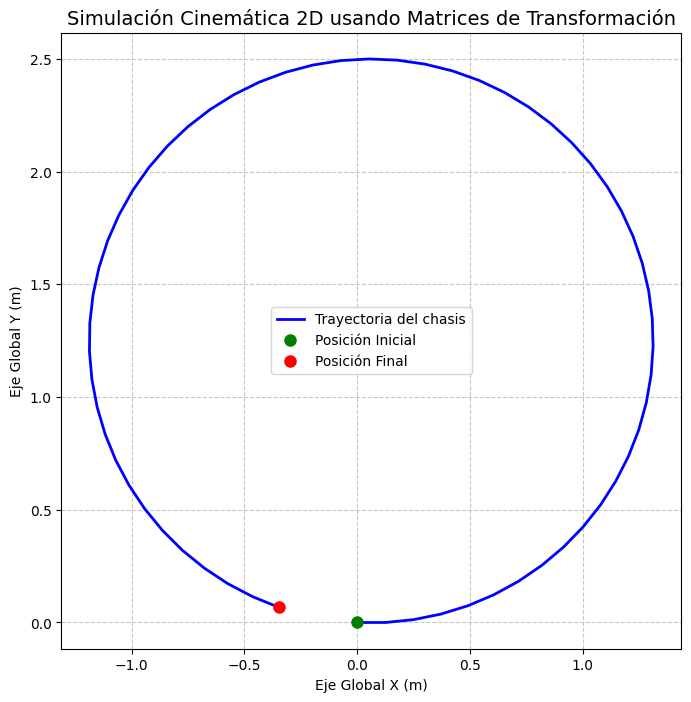

In [7]:
# Definición de parámetros del robot
R = 0.1
L = 0.5
dt = 0.1
tiempo_total = 6.0

# Condiciones iniciales en el Sistema Global: [x=0, y=0, theta=0]
pose = [0.0, 0.0, 0.0]

# Listas para almacenar el historial de posiciones (para la gráfica)
historial_x = [pose[0]]
historial_y = [pose[1]]
historial_theta = [pose[2]]

# Entradas de control: Velocidades de las ruedas en rad/s
# (Si w_R es diferente de w_L, el robot describirá un arco o un círculo)
w_R = 15.0
w_L = 10.0

# Bucle principal de simulación temporal
for t in np.arange(0, tiempo_total, dt):
    # Calcular nueva posición con nuestra función matricial
    pose = modelo_cinematico_diferencial(pose, w_R, w_L, R, L, dt)

    # Guardar coordenadas para el trazado
    historial_x.append(pose[0])
    historial_y.append(pose[1])
    historial_theta.append(pose[2])

# --- Visualización de la Trayectoria ---
plt.figure(figsize=(8, 8))
plt.plot(historial_x, historial_y, '-b', linewidth=2, label="Trayectoria del chasis")
plt.plot(historial_x[0], historial_y[0], 'go', markersize=8, label="Posición Inicial")
plt.plot(historial_x[-1], historial_y[-1], 'ro', markersize=8, label="Posición Final")

# Formato estético del gráfico
plt.title("Simulación Cinemática 2D usando Matrices de Transformación", fontsize=14)
plt.xlabel("Eje Global X (m)")
plt.ylabel("Eje Global Y (m)")
plt.axis("equal") # Crucial para ver arcos reales y no distorsionados
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [8]:
import matplotlib.animation as animation
from IPython.display import HTML

# 1. Configurar la figura base
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Animación del Movimiento del Robot", fontsize=14)
ax.set_xlabel("Eje Global X (m)")
ax.set_ylabel("Eje Global Y (m)")
ax.axis("equal")
ax.grid(True, linestyle='--', alpha=0.7)

# Ajustar los límites del gráfico dinámicamente según la trayectoria
margen = 0.5
ax.set_xlim(min(historial_x) - margen, max(historial_x) + margen)
ax.set_ylim(min(historial_y) - margen, max(historial_y) + margen)

# 2. Inicializar los elementos gráficos vacíos
linea_trayectoria, = ax.plot([], [], '-b', alpha=0.5, label="Trayectoria")
punto_robot, = ax.plot([], [], 'ro', markersize=10, label="Chasis")
linea_orientacion, = ax.plot([], [], '-k', linewidth=2, label="Frente del robot")

ax.legend(loc="upper left")

# 3. Función de inicialización para la animación
def init():
    linea_trayectoria.set_data([], [])
    punto_robot.set_data([], [])
    linea_orientacion.set_data([], [])
    return linea_trayectoria, punto_robot, linea_orientacion

# 4. Función que actualiza los gráficos en cada frame 'i'
def animate(i):
    # Actualizar la estela de la trayectoria hasta el instante actual 'i'
    linea_trayectoria.set_data(historial_x[:i+1], historial_y[:i+1])

    # Actualizar la posición del robot
    x_actual = historial_x[i]
    y_actual = historial_y[i]
    theta_actual = historial_theta[i]
    punto_robot.set_data([x_actual], [y_actual])

    # Calcular y dibujar una pequeña línea para mostrar hacia dónde mira el robot
    longitud_indicador = 0.3
    x_dir = [x_actual, x_actual + longitud_indicador * np.cos(theta_actual)]
    y_dir = [y_actual, y_actual + longitud_indicador * np.sin(theta_actual)]
    linea_orientacion.set_data(x_dir, y_dir)

    return linea_trayectoria, punto_robot, linea_orientacion

# 5. Crear la animación
# interval=50 significa 50 milisegundos entre frames
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(historial_x),
                              interval=50, blit=True)

# Cerrar el plot estático para que no se muestre por duplicado debajo del video
plt.close(fig)

# 6. Mostrar la animación como un widget interactivo HTML5
HTML(ani.to_jshtml())